In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("predictive_maintenance_dataset.csv")

In [3]:
# =========================
#    Dataset Overview
# =========================
print("\n--- Dataset Shape ---")
print(df.shape)

print("\n--- First 5 Rows ---")
print(df.head())

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Summary Statistics ---")
print(df.describe(include='all').T)


--- Dataset Shape ---
(124494, 12)

--- First 5 Rows ---
       date    device  failure    metric1  metric2  metric3  metric4  metric5  \
0  1/1/2015  S1F01085        0  215630672       55        0       52        6   
1  1/1/2015  S1F0166B        0   61370680        0        3        0        6   
2  1/1/2015  S1F01E6Y        0  173295968        0        0        0       12   
3  1/1/2015  S1F01JE0        0   79694024        0        0        0        6   
4  1/1/2015  S1F01R2B        0  135970480        0        0        0       15   

   metric6  metric7  metric8  metric9  
0   407438        0        0        7  
1   403174        0        0        0  
2   237394        0        0        0  
3   410186        0        0        0  
4   313173        0        0        3  

--- Data Types ---
date       object
device     object
failure     int64
metric1     int64
metric2     int64
metric3     int64
metric4     int64
metric5     int64
metric6     int64
metric7     int64
metric8     int

In [4]:
# =========================
#    Identify Columns
# =========================
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
categorical_cols = df.select_dtypes(exclude=np.number).columns.tolist()

failure_col = None
for col in df.columns:
    if 'failure' in col.lower() or 'target' in col.lower():
        failure_col = col
        break

if not failure_col:
    raise ValueError("No failure/target column found. Please update 'failure_col' manually.")



--- Failure Column Value Counts ---
failure
0    124388
1       106
Name: count, dtype: int64
failure
0    0.999149
1    0.000851
Name: proportion, dtype: float64


C:\Users\chenn\AppData\Local\Temp\ipykernel_17976\1938269222.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=failure_col, data=df, palette="Set2")


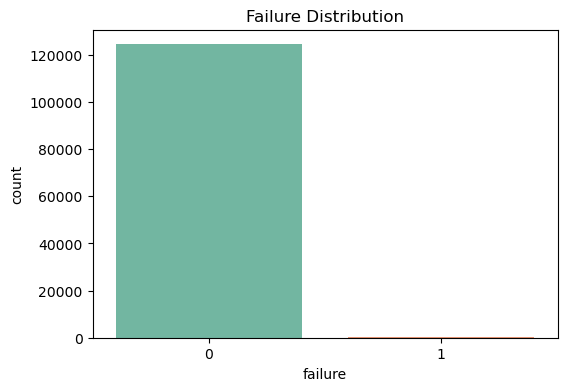

In [5]:
# =========================
#  Class Imbalance Check
# =========================
print("\n--- Failure Column Value Counts ---")
print(df[failure_col].value_counts())
print(df[failure_col].value_counts(normalize=True))

plt.figure(figsize=(6,4))
sns.countplot(x=failure_col, hue=failure_col, data=df, palette="Set2", legend=False)
plt.title("Failure Distribution")
plt.show()

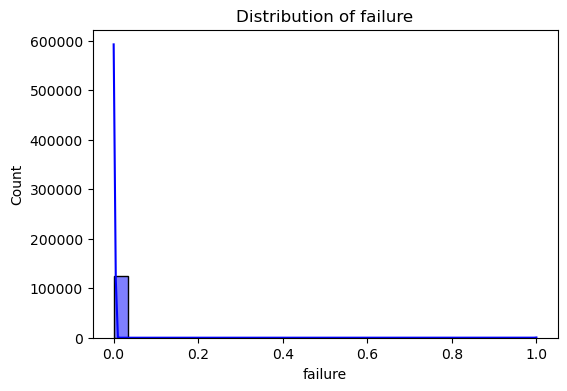

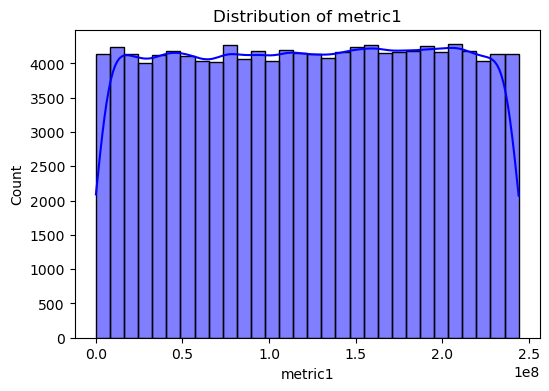

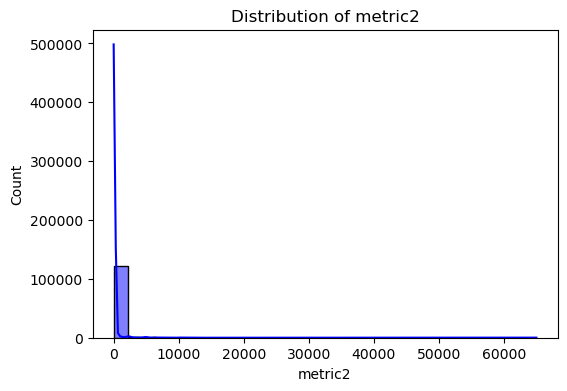

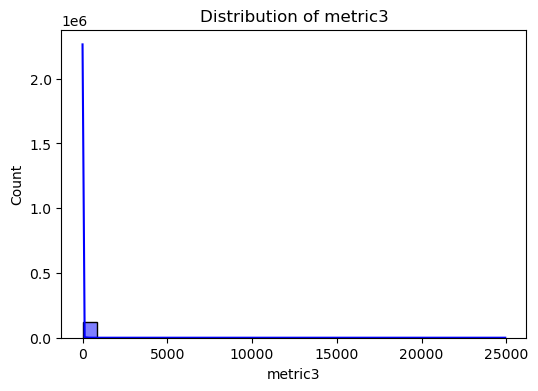

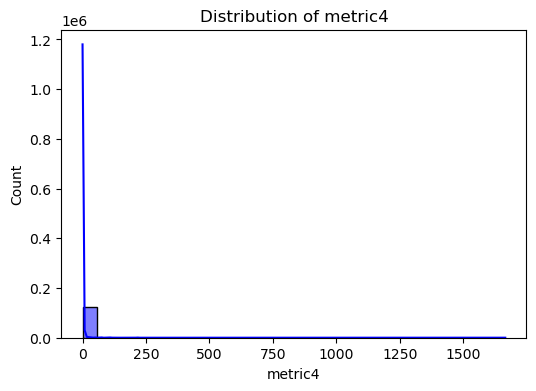

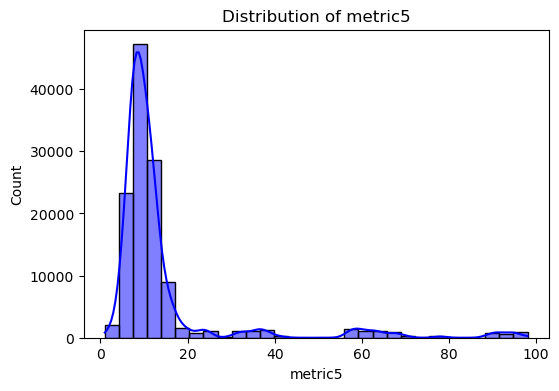

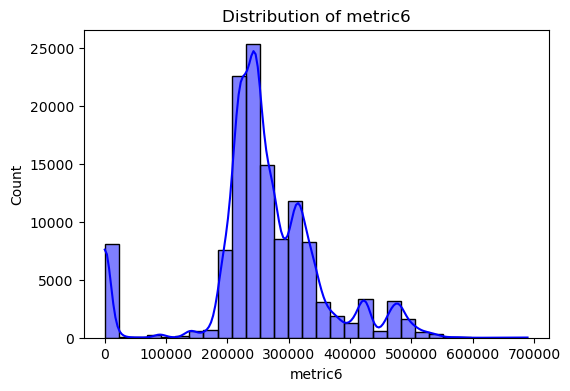

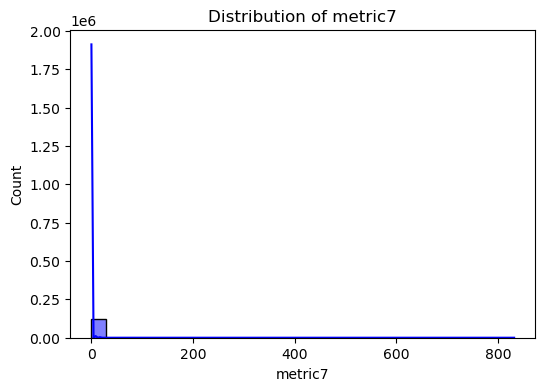

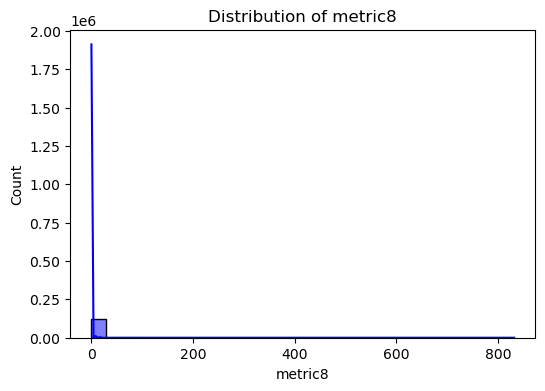

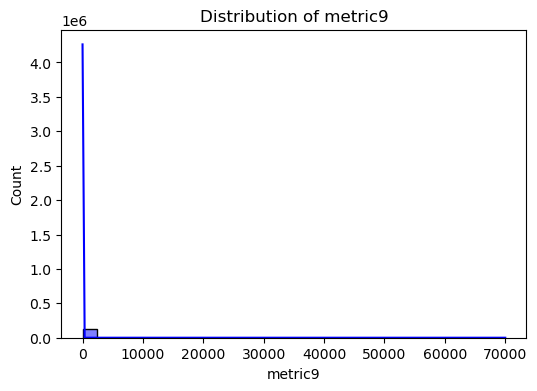

In [6]:
# ====================================
#   Distribution of Numeric Features
# ====================================
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30, color='blue')
    plt.title(f"Distribution of {col}")
    plt.show()


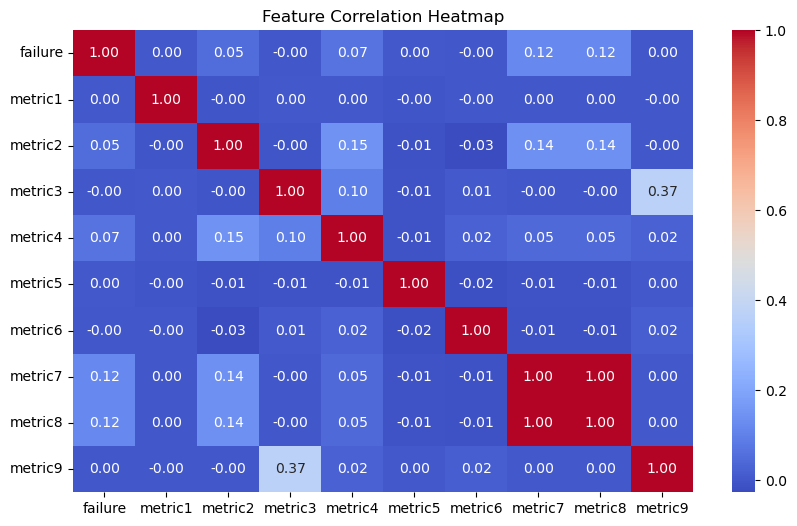

In [7]:
# =========================
#   Correlation Heatmap
# =========================
plt.figure(figsize=(10,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

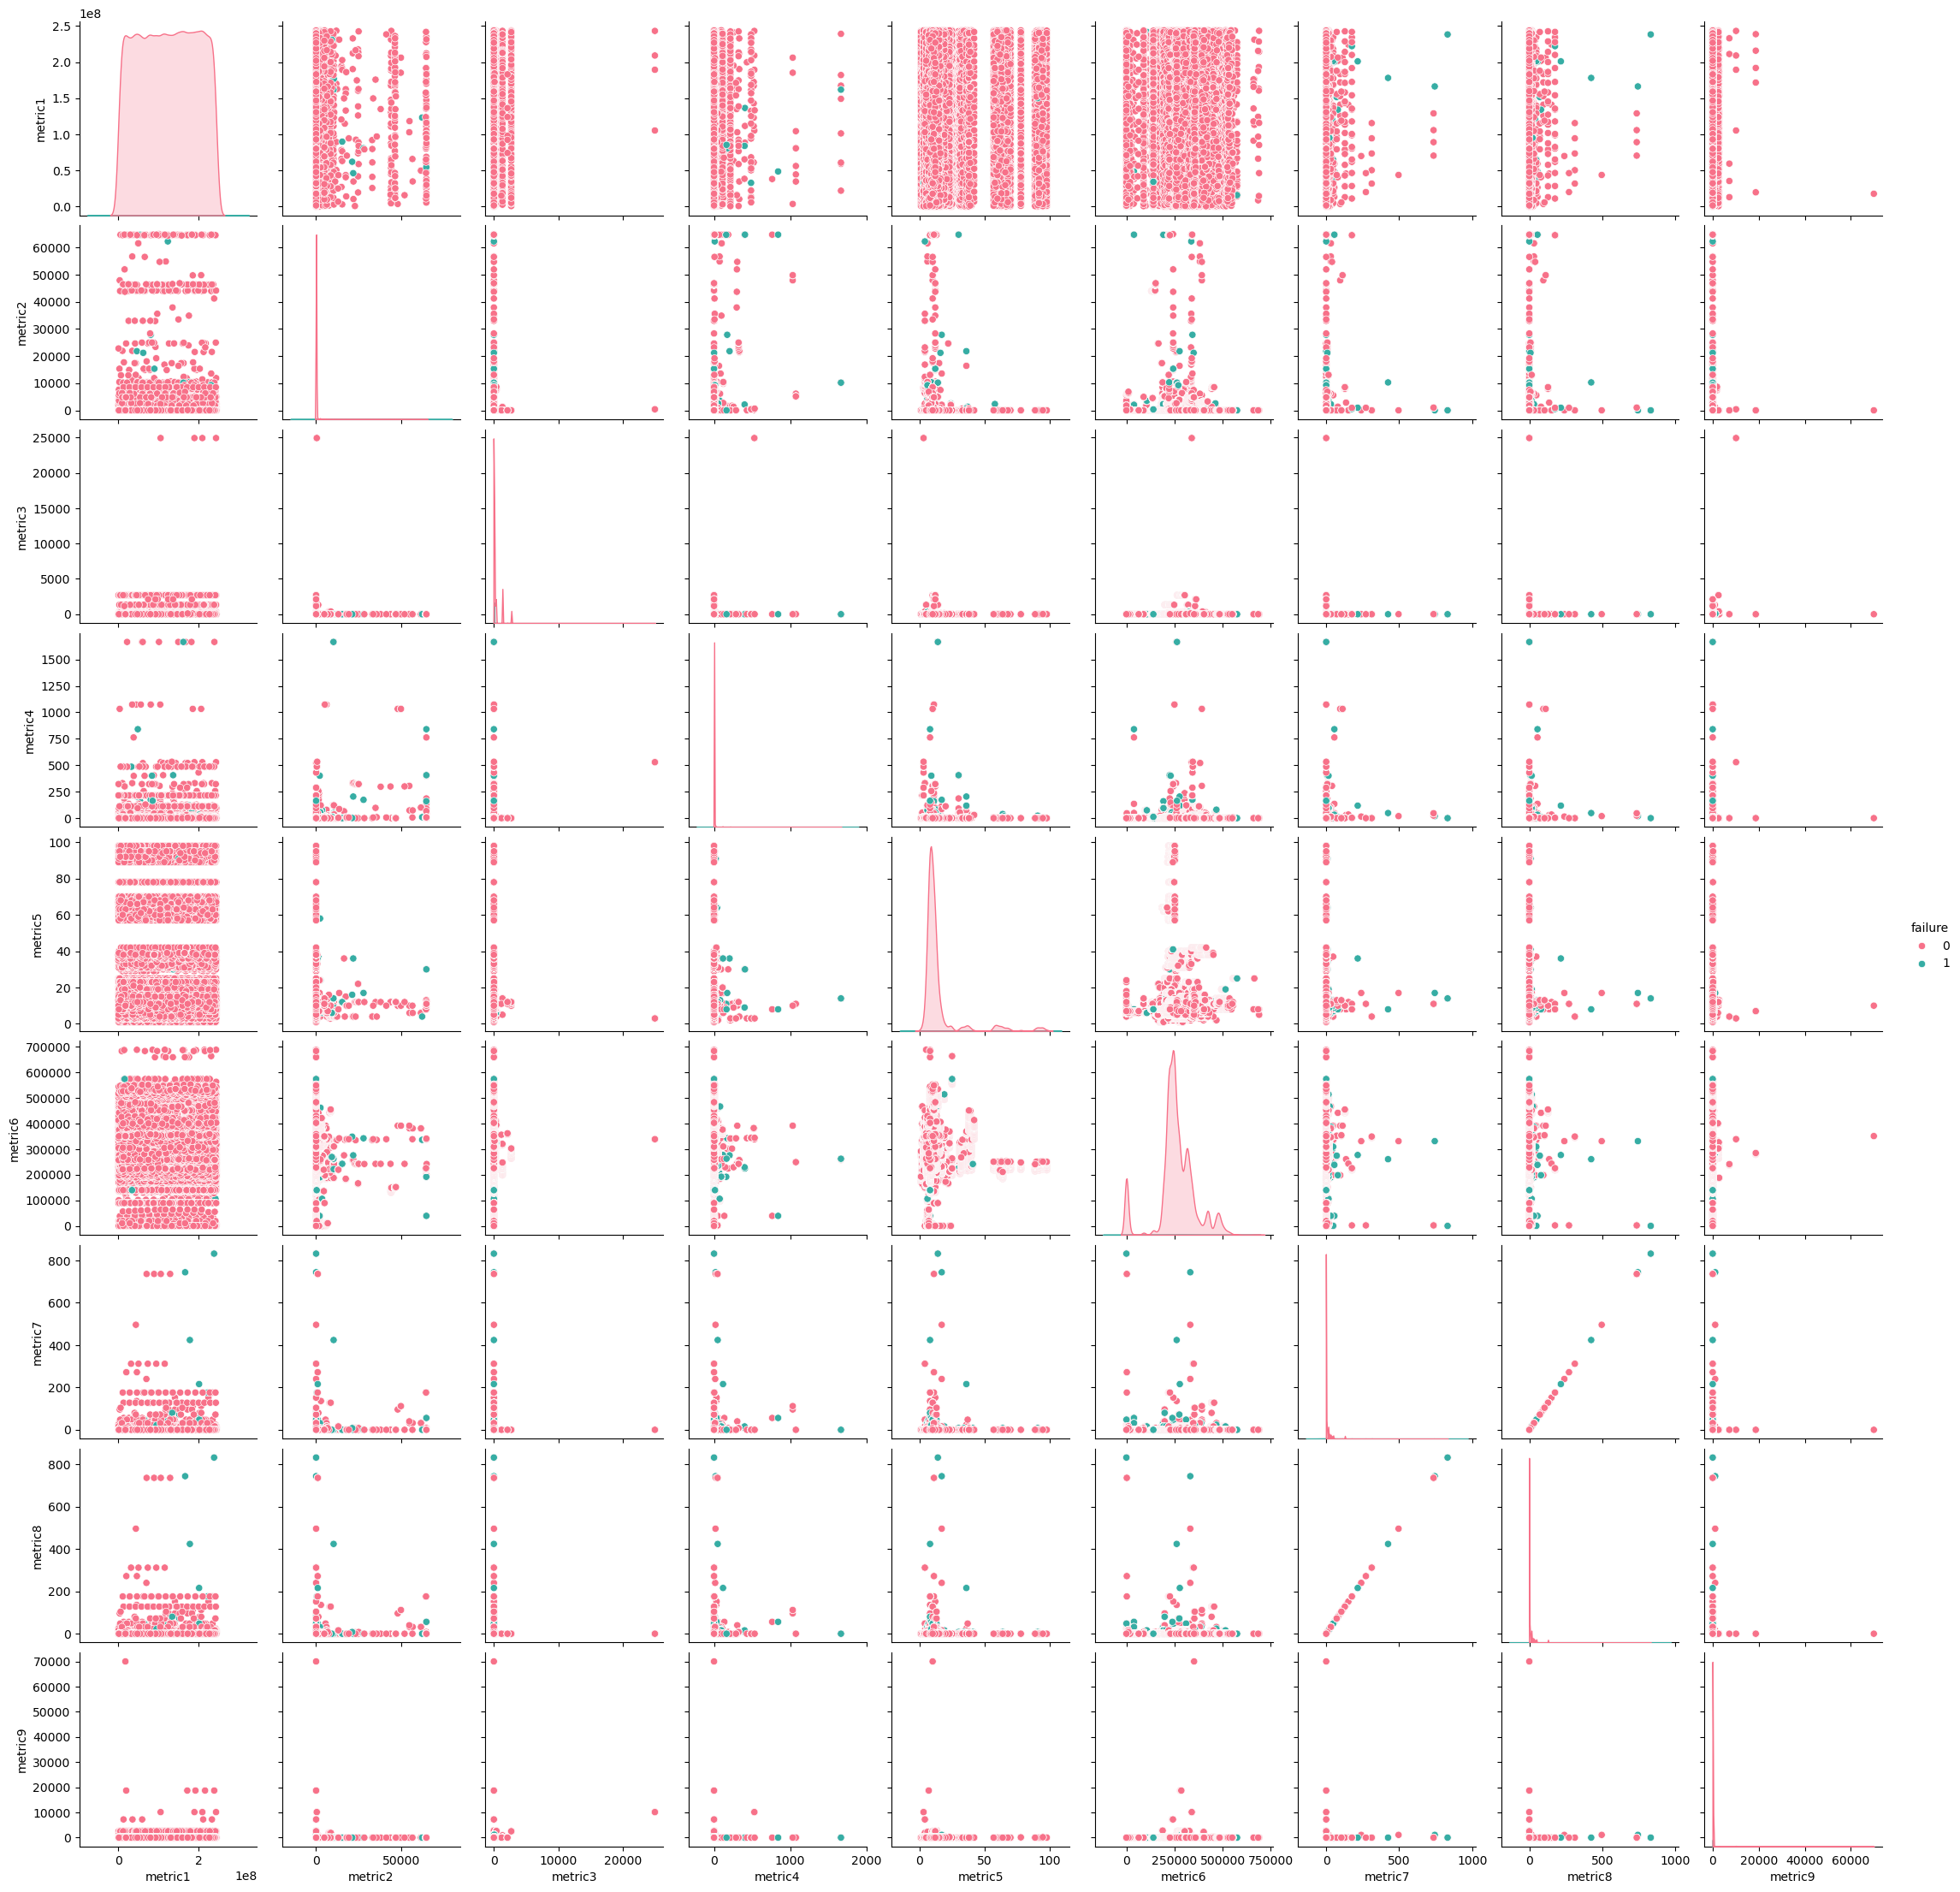

In [9]:
# ===================================
# Pairplot for All Numeric Features
# ===================================
pairplot_cols = list(dict.fromkeys(numeric_cols + [failure_col]))
sns.pairplot(
    df[pairplot_cols],
    hue=failure_col,
    diag_kind="kde",
    palette="husl"
)
plt.show()

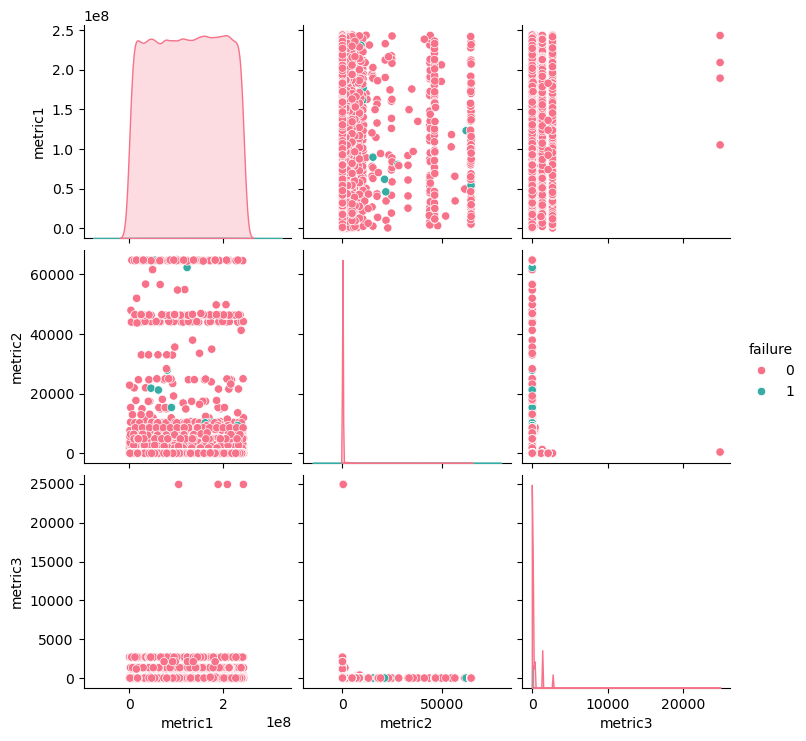

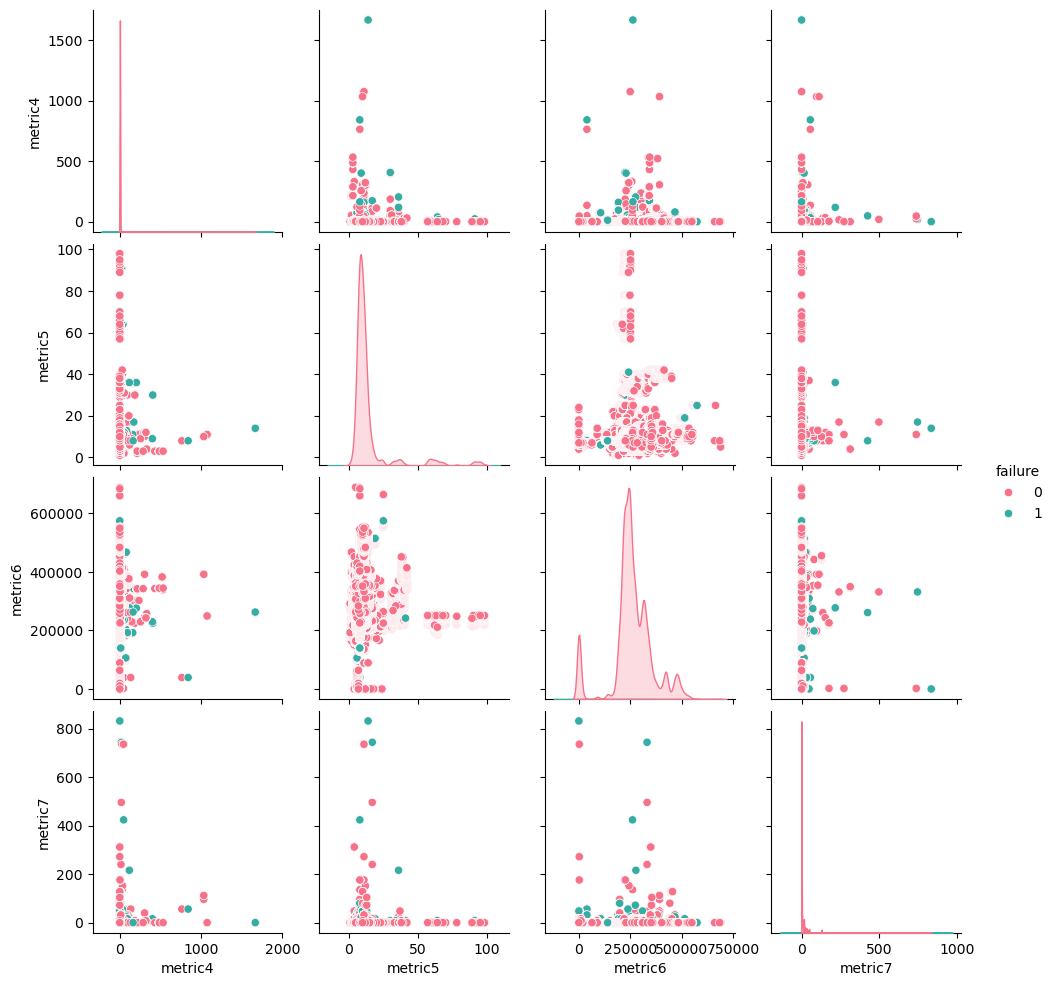

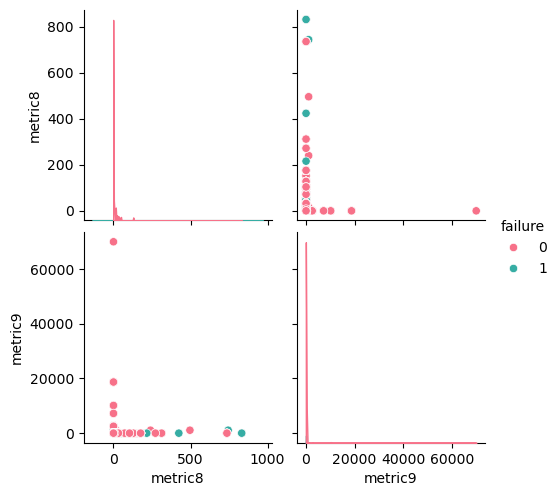

In [10]:
# ==========================================
# Batched Pairplots for Better Readability
# ==========================================
batch_size = 4
for i in range(0, len(numeric_cols), batch_size):
    sample_cols = numeric_cols[i:i+batch_size]
    cols_to_plot = sample_cols + [failure_col] if failure_col not in sample_cols else sample_cols
    sns.pairplot(
        df[cols_to_plot],
        hue=failure_col,
        diag_kind="kde",
        palette="husl"
    )
    plt.show()

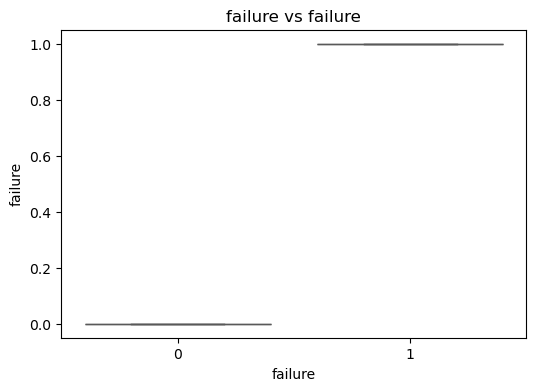

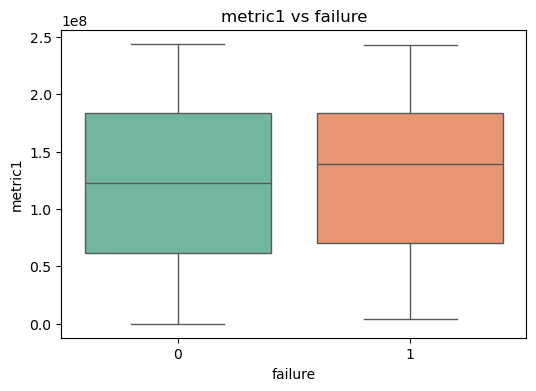

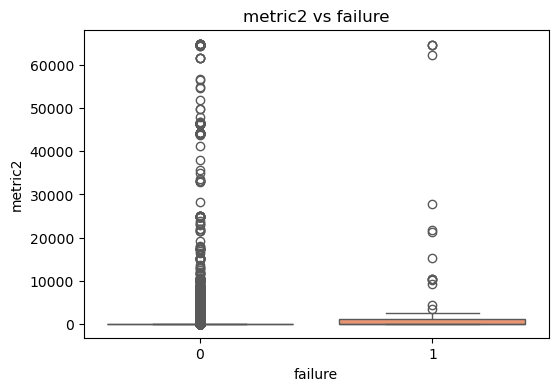

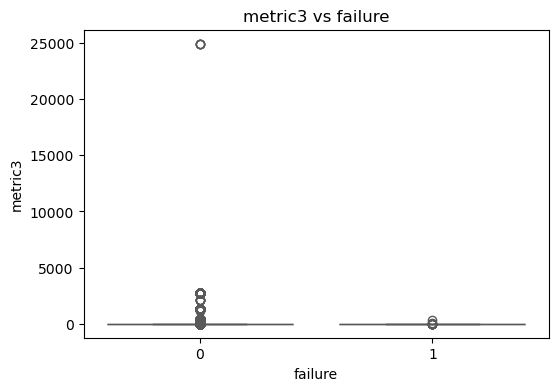

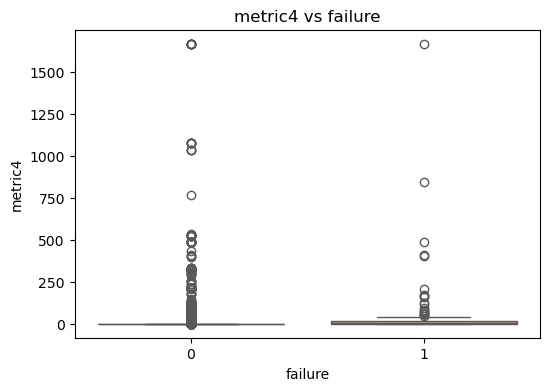

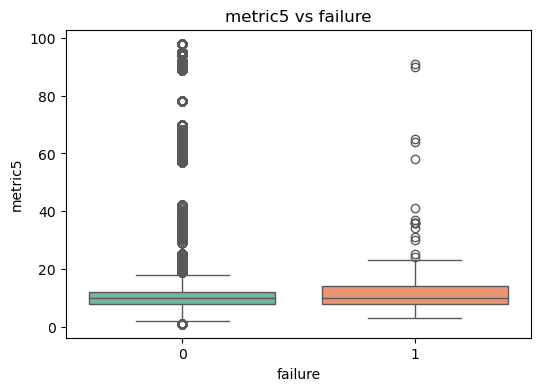

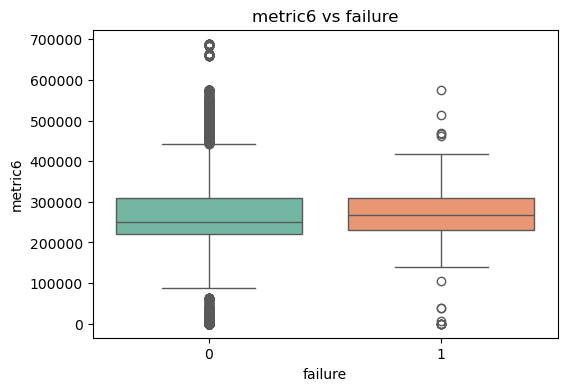

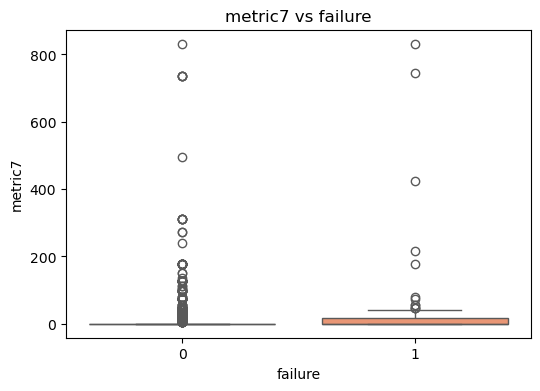

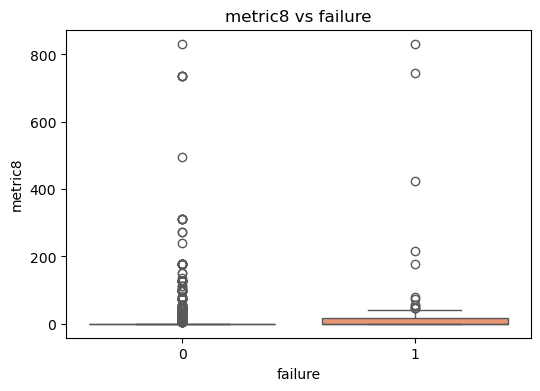

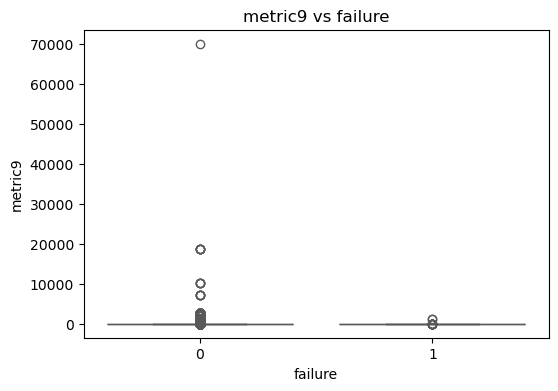

In [14]:
# ==================================
#  Boxplots per Feature vs Failure
# ==================================
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=failure_col, y=col, hue=failure_col, data=df, palette="Set2", legend=False)
    plt.title(f"{col} vs {failure_col}")
    plt.show()


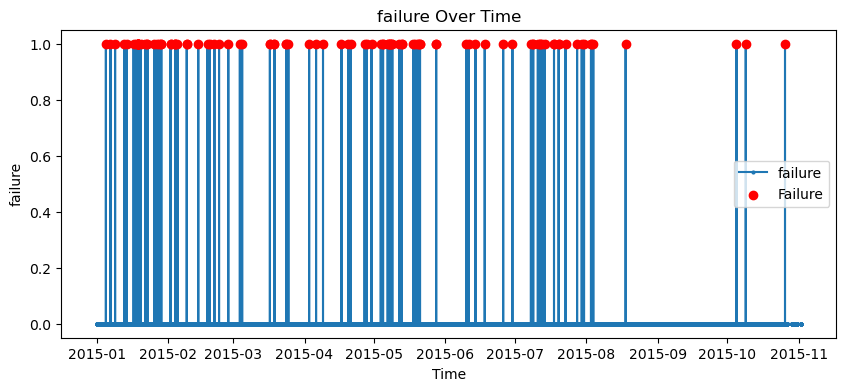

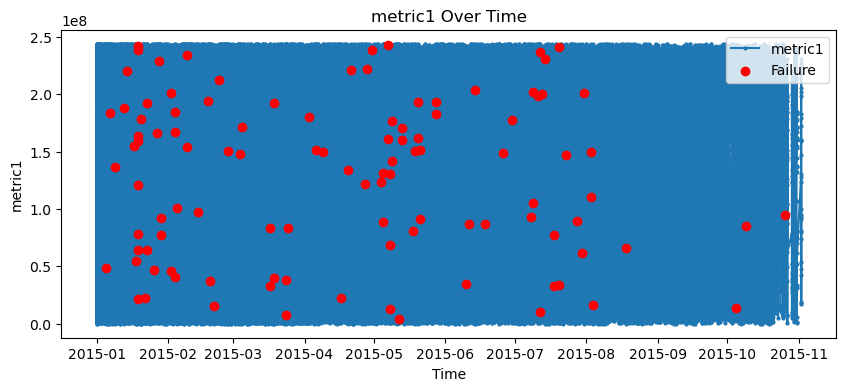

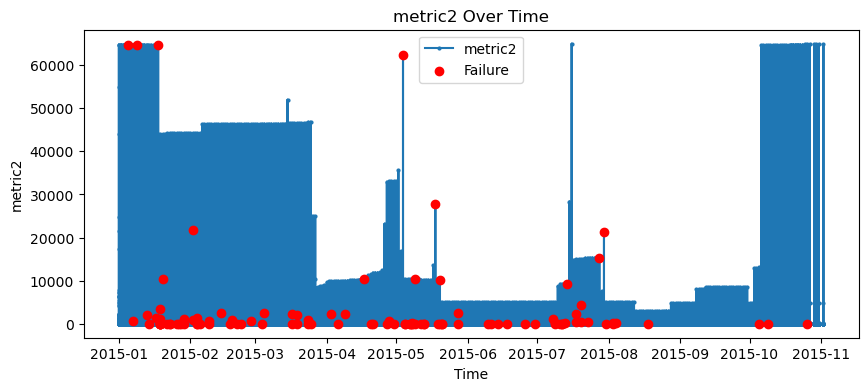

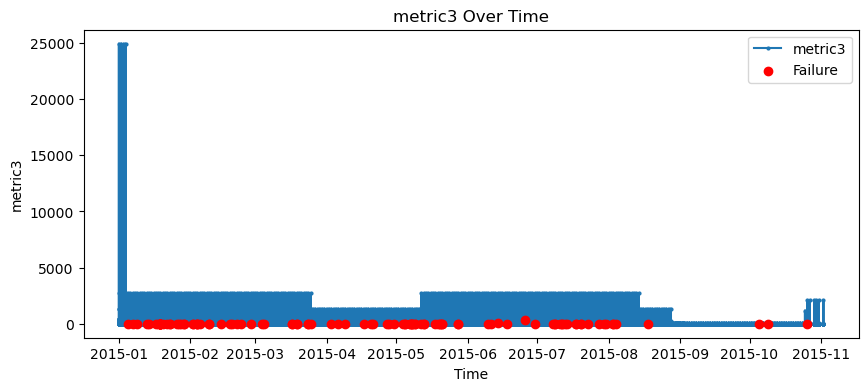

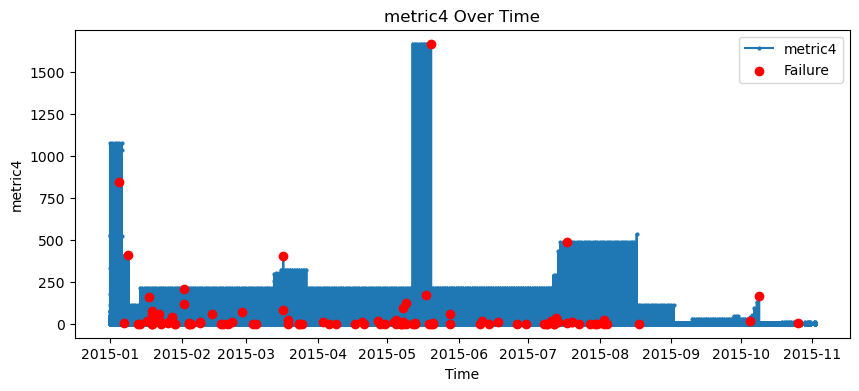

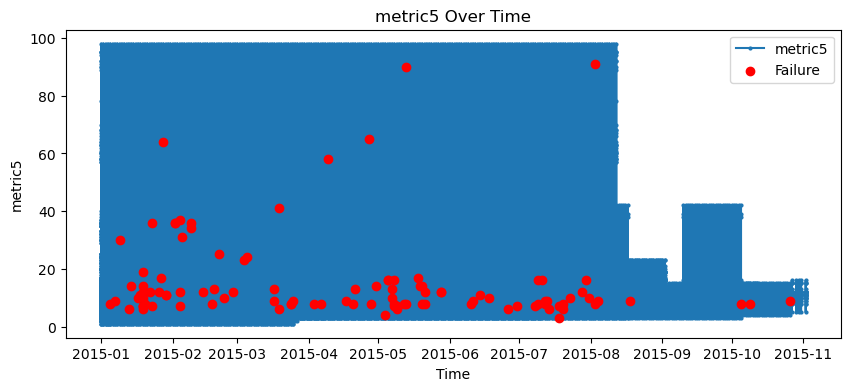

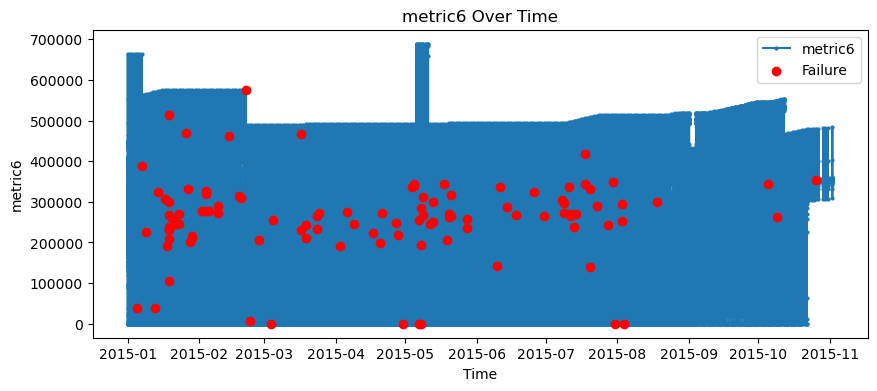

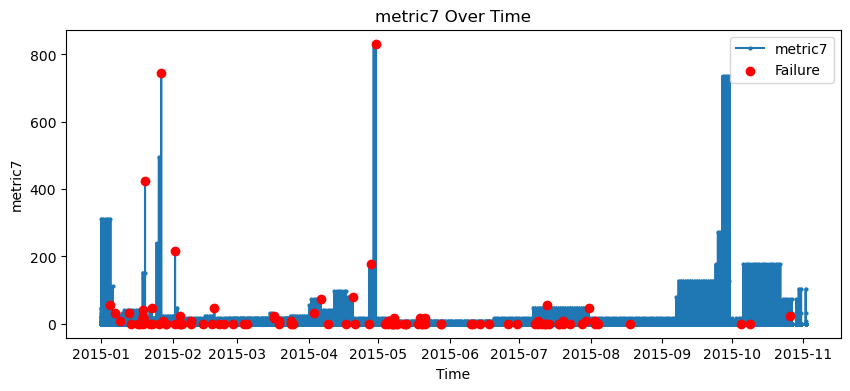

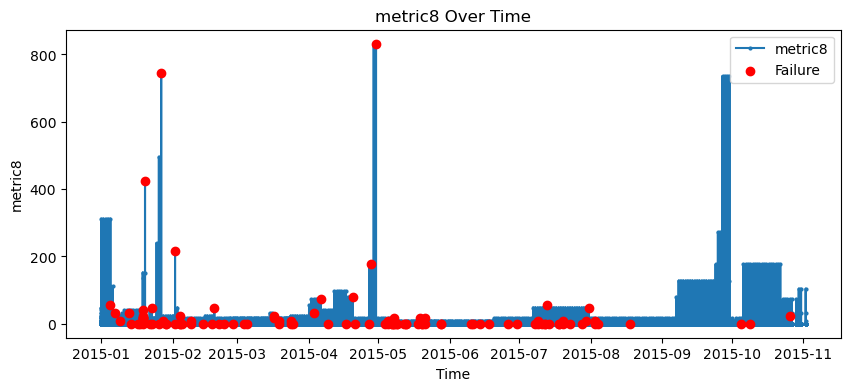

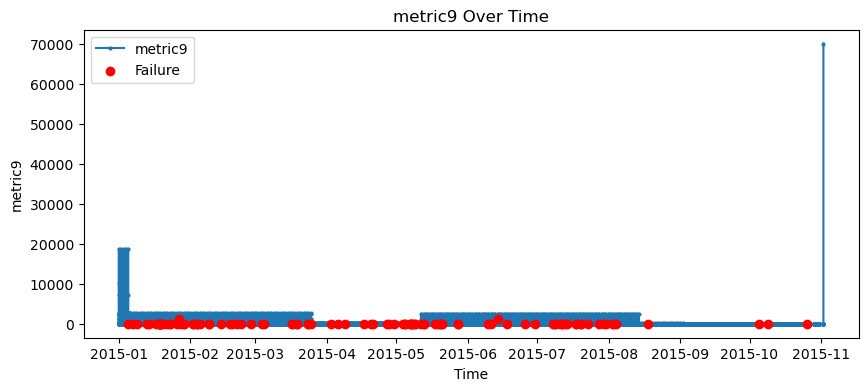

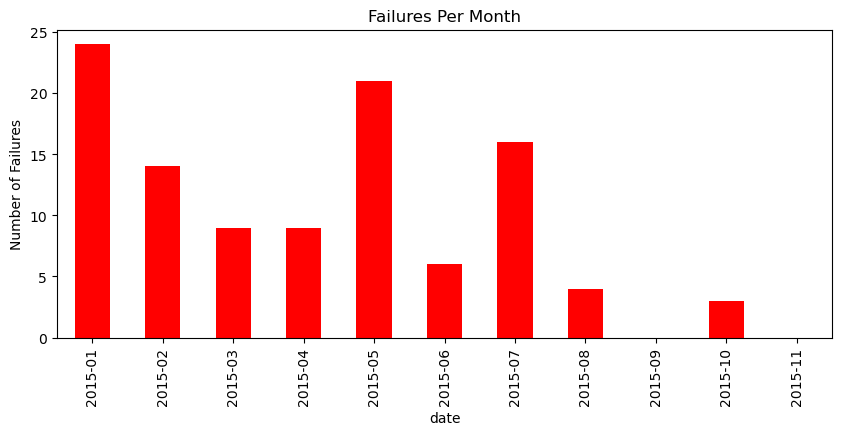

In [15]:
# =========================
#   Time-Series Analysis
# =========================
possible_time_cols = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]
if possible_time_cols:
    time_col = possible_time_cols[0]
    df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
    df = df.sort_values(by=time_col)

    # Plot all numeric columns over time
    for col in numeric_cols:
        plt.figure(figsize=(10,4))
        plt.plot(df[time_col], df[col], marker='o', linestyle='-', markersize=2, label=col)
        fail_times = df[df[failure_col] == 1]
        plt.scatter(fail_times[time_col], fail_times[col], color='red', label='Failure', zorder=5)
        plt.title(f"{col} Over Time")
        plt.xlabel("Time")
        plt.ylabel(col)
        plt.legend()
        plt.show()

    # Failures per Month
    failures_per_month = df.groupby(df[time_col].dt.to_period('M'))[failure_col].sum()
    failures_per_month.plot(kind='bar', figsize=(10,4), color='red')
    plt.title("Failures Per Month")
    plt.ylabel("Number of Failures")
    plt.show()